<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/QFT2001b.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Starting QFT2001b 3D evolution (localized bump): L=64, N_int=100, steps= 1000
t=   0  var_x=1.631e-06  vac_E=6.538e-05  max_amp=5.206e-02  patch_amp=3.709e-02
t=  10  var_x=2.350e-06  vac_E=6.804e-05  max_amp=4.393e-02  patch_amp=3.357e-02
t=  20  var_x=1.298e-06  vac_E=3.100e-05  max_amp=3.185e-02  patch_amp=2.590e-02
t=  30  var_x=8.875e-07  vac_E=2.093e-05  max_amp=2.415e-02  patch_amp=2.000e-02
t=  40  var_x=7.377e-07  vac_E=1.750e-05  max_amp=1.987e-02  patch_amp=1.637e-02
t=  50  var_x=6.804e-07  vac_E=1.630e-05  max_amp=1.685e-02  patch_amp=1.409e-02
t=  60  var_x=6.574e-07  vac_E=1.585e-05  max_amp=1.490e-02  patch_amp=1.264e-02
t=  70  var_x=6.475e-07  vac_E=1.571e-05  max_amp=1.367e-02  patch_amp=1.171e-02
t=  80  var_x=6.429e-07  vac_E=1.566e-05  max_amp=1.295e-02  patch_amp=1.095e-02
t=  90  var_x=6.408e-07  vac_E=1.564e-05  max_amp=1.225e-02  patch_amp=1.039e-02
t= 100  var_x=6.396e-07  vac_E=1.564e-05  max_amp=1.204e-02  patch_amp=9.975e-03
t= 110  var_x=6.386e-07  vac_E=

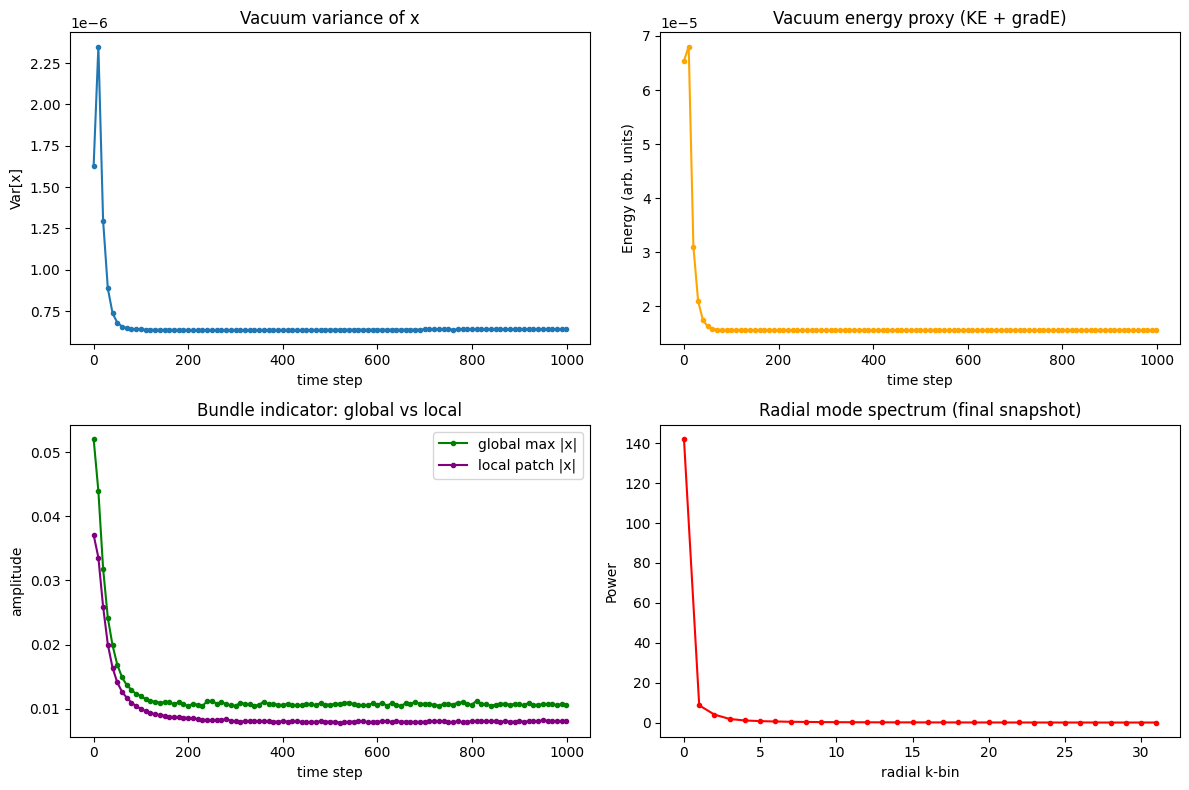


--- QFT2001b qualitative checks ---
Final vacuum variance: 6.410922740680513e-07
Final vacuum energy proxy: 1.5625608374145624e-05
Final global max amplitude: 0.01063623987509581
Final local patch amplitude: 0.008079077500682378
Mode spectra samples: 101 snapshots


In [1]:
# QFT2001b — Localized bundle test (3D, 64³, N=100)
# Colab-ready, single block.

import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1. Core parameters
# -----------------------------
L = 64
N_int = 100

lambda_c = 0.02
gamma = 0.10
noise_amp = 1e-4
n_steps = 1000
save_every = 10

rng = np.random.default_rng(2001)

shape_field = (L, L, L, N_int)

def laplacian_3d_periodic(field):
    xp = np.roll(field, +1, axis=0)
    xm = np.roll(field, -1, axis=0)
    yp = np.roll(field, +1, axis=1)
    ym = np.roll(field, -1, axis=1)
    zp = np.roll(field, +1, axis=2)
    zm = np.roll(field, -1, axis=2)
    lap = (xp + xm + yp + ym + zp + zm - 6.0 * field)
    return lap

# -----------------------------
# 2. Initialize fields with a localized Gaussian bump
# -----------------------------
# Base vacuum noise
x = 1e-3 * rng.standard_normal(size=shape_field).astype(np.float64)
v = 1e-3 * rng.standard_normal(size=shape_field).astype(np.float64)

# Define bump centre and width
cx, cy, cz = L // 2, L // 2, L // 2
sigma = 4.0
amp_bump = 0.05  # amplitude of localized excitation

X = np.arange(L)
Y = np.arange(L)
Z = np.arange(L)
XX, YY, ZZ = np.meshgrid(X, Y, Z, indexing='ij')

dx = XX - cx
dy = YY - cy
dz = ZZ - cz
r2 = dx**2 + dy**2 + dz**2

gauss = np.exp(-r2 / (2.0 * sigma**2))  # (L, L, L)

# Imprint bump into a single internal component (dim 0)
x[..., 0] += amp_bump * gauss

# -----------------------------
# 3. Diagnostics storage
# -----------------------------
times = []
vacuum_var = []
vacuum_energy = []
mode_spectra = []
max_local_amp = []

# Track local patch average around the bump centre
patch_radius = 3
patch_amp = []

def compute_diagnostics(t, x, v):
    var_x = np.var(x)

    ke = np.mean(v**2)
    lap_x = laplacian_3d_periodic(x)
    ge = np.mean(lap_x**2)
    vac_E = ke + ge

    amp = np.sqrt(np.sum(x**2, axis=-1))  # (L, L, L)
    max_amp = np.max(amp)

    # Local patch around bump centre
    r = patch_radius
    xs = slice(cx - r, cx + r + 1)
    ys = slice(cy - r, cy + r + 1)
    zs = slice(cz - r, cz + r + 1)
    local_patch = amp[xs, ys, zs]
    local_mean = np.mean(local_patch)

    # Mode spectrum (single component)
    comp = x[..., 0]
    fft3 = np.fft.fftn(comp)
    power3 = np.abs(fft3)**2

    kx = np.fft.fftfreq(L)
    ky = np.fft.fftfreq(L)
    kz = np.fft.fftfreq(L)
    KX, KY, KZ = np.meshgrid(kx, ky, kz, indexing='ij')
    kr = np.sqrt(KX**2 + KY**2 + KZ**2)

    n_bins = L // 2
    bins = np.linspace(0, np.max(kr), n_bins + 1)
    radial_power = np.zeros(n_bins, dtype=np.float64)
    counts = np.zeros(n_bins, dtype=np.int64)

    kr_flat = kr.ravel()
    p_flat = power3.ravel()
    inds = np.digitize(kr_flat, bins) - 1
    valid = (inds >= 0) & (inds < n_bins)
    for i, p in zip(inds[valid], p_flat[valid]):
        radial_power[i] += p
        counts[i] += 1
    counts[counts == 0] = 1
    radial_power /= counts

    return var_x, vac_E, radial_power, max_amp, local_mean

# -----------------------------
# 4. Main evolution
# -----------------------------
print("Starting QFT2001b 3D evolution (localized bump): L=64, N_int=100, steps=", n_steps)

for t in range(n_steps):
    lap_x = laplacian_3d_periodic(x)
    eta = noise_amp * rng.standard_normal(size=shape_field).astype(np.float64)

    v = v + lambda_c * lap_x - gamma * v + eta
    x = x + v

    if t % save_every == 0 or t == n_steps - 1:
        var_x, vac_E, radial_power, max_amp, local_mean = compute_diagnostics(t, x, v)
        times.append(t)
        vacuum_var.append(var_x)
        vacuum_energy.append(vac_E)
        mode_spectra.append(radial_power)
        max_local_amp.append(max_amp)
        patch_amp.append(local_mean)
        print(f"t={t:4d}  var_x={var_x:.3e}  vac_E={vac_E:.3e}  "
              f"max_amp={max_amp:.3e}  patch_amp={local_mean:.3e}")

print("Evolution complete.")

times = np.array(times)
vacuum_var = np.array(vacuum_var)
vacuum_energy = np.array(vacuum_energy)
mode_spectra = np.array(mode_spectra)
max_local_amp = np.array(max_local_amp)
patch_amp = np.array(patch_amp)

# -----------------------------
# 5. Plots
# -----------------------------
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

axs[0, 0].plot(times, vacuum_var, '-o', ms=3)
axs[0, 0].set_title("Vacuum variance of x")
axs[0, 0].set_xlabel("time step")
axs[0, 0].set_ylabel("Var[x]")

axs[0, 1].plot(times, vacuum_energy, '-o', ms=3, color='orange')
axs[0, 1].set_title("Vacuum energy proxy (KE + gradE)")
axs[0, 1].set_xlabel("time step")
axs[0, 1].set_ylabel("Energy (arb. units)")

axs[1, 0].plot(times, max_local_amp, '-o', ms=3, color='green', label='global max |x|')
axs[1, 0].plot(times, patch_amp, '-o', ms=3, color='purple', label='local patch |x|')
axs[1, 0].set_title("Bundle indicator: global vs local")
axs[1, 0].set_xlabel("time step")
axs[1, 0].set_ylabel("amplitude")
axs[1, 0].legend()

if mode_spectra.shape[0] > 0:
    final_spec = mode_spectra[-1]
    axs[1, 1].plot(final_spec, '-o', ms=3, color='red')
    axs[1, 1].set_title("Radial mode spectrum (final snapshot)")
    axs[1, 1].set_xlabel("radial k-bin")
    axs[1, 1].set_ylabel("Power")

plt.tight_layout()
plt.show()

# -----------------------------
# 6. Summary
# -----------------------------
print("\n--- QFT2001b qualitative checks ---")
print("Final vacuum variance:", vacuum_var[-1])
print("Final vacuum energy proxy:", vacuum_energy[-1])
print("Final global max amplitude:", max_local_amp[-1])
print("Final local patch amplitude:", patch_amp[-1])
print("Mode spectra samples:", mode_spectra.shape[0], "snapshots")
